# Code for the exam in 02407 - Stochastic processes/probability 2

Imports: 

In [1]:
import sympy as sp
import numpy as np
from scipy.linalg import expm
# For prettier printing :))
sp.init_printing()

## Part 1

### Question 1
Calculating the transition matrix P.

In [2]:
rate = sp.Rational(5,2)
p = sp.Rational(1,3)

def A_(n):
    if n < 0:
        return 0
    return sp.exp(-rate) * rate**n / sp.factorial(n)
def C_(i, k):
    return sp.binomial(i, k) * p**k * (1 - p)**(i - k) 

#Transition probabilitiy from i to j cases
def tP(i,j,dim=7):
    if min(i,j) < 0:
        raise ValueError("i and j must be non-negative")
    Delta = j - i
    if j < dim-1:
        return sum([C_(i, k)*(A_(Delta + k)) for k in range(i+1)])
    
    return 1 - sum([tP(i,J,dim) for J in range(dim-1)]) # Using that P is a stochastic matrix

dim = 7

P = sp.Matrix(dim,dim, [tP(i,j,dim) for i in range(dim) for j in range(dim)])
display(P.evalf(2))
print("Row sums: ", [ (sp.simplify(sum(P[i, j] for j in range(dim)))).evalf() for i in range(dim) ])


⎡ 0.082    0.21   0.26   0.21   0.13   0.067  0.042⎤
⎢                                                  ⎥
⎢ 0.027    0.12   0.22   0.24   0.19   0.11   0.087⎥
⎢                                                  ⎥
⎢0.0091   0.059   0.16   0.23   0.22   0.16   0.16 ⎥
⎢                                                  ⎥
⎢ 0.003   0.026   0.092  0.18   0.23    0.2   0.27 ⎥
⎢                                                  ⎥
⎢ 0.001   0.011   0.048  0.12    0.2   0.22    0.4 ⎥
⎢                                                  ⎥
⎢0.00034  0.0042  0.023  0.072  0.15    0.2   0.55 ⎥
⎢                                                  ⎥
⎣0.00011  0.0016  0.01   0.039  0.097  0.17   0.69 ⎦

Row sums:  [1.00000000000000, 1.00000000000000, 1.00000000000000, 1.00000000000000, 1.00000000000000, 1.00000000000000, 1.00000000000000]


In [3]:
print(sp.latex(P.evalf(4)))
P.evalf(2)

\left[\begin{matrix}0.08208 & 0.2052 & 0.2565 & 0.2138 & 0.1336 & 0.0668 & 0.04202\\0.02736 & 0.1231 & 0.2223 & 0.2423 & 0.187 & 0.1113 & 0.08656\\0.009121 & 0.05928 & 0.1562 & 0.229 & 0.2239 & 0.1618 & 0.1608\\0.00304 & 0.02584 & 0.09159 & 0.1804 & 0.2273 & 0.2032 & 0.2687\\0.001013 & 0.01064 & 0.04776 & 0.1212 & 0.1961 & 0.2192 & 0.4041\\0.0003378 & 0.004222 & 0.02301 & 0.07224 & 0.1462 & 0.2038 & 0.5503\\0.0001126 & 0.001633 & 0.01049 & 0.03942 & 0.09688 & 0.1654 & 0.6861\end{matrix}\right]


⎡ 0.082    0.21   0.26   0.21   0.13   0.067  0.042⎤
⎢                                                  ⎥
⎢ 0.027    0.12   0.22   0.24   0.19   0.11   0.087⎥
⎢                                                  ⎥
⎢0.0091   0.059   0.16   0.23   0.22   0.16   0.16 ⎥
⎢                                                  ⎥
⎢ 0.003   0.026   0.092  0.18   0.23    0.2   0.27 ⎥
⎢                                                  ⎥
⎢ 0.001   0.011   0.048  0.12    0.2   0.22    0.4 ⎥
⎢                                                  ⎥
⎢0.00034  0.0042  0.023  0.072  0.15    0.2   0.55 ⎥
⎢                                                  ⎥
⎣0.00011  0.0016  0.01   0.039  0.097  0.17   0.69 ⎦

### Question 2

In [4]:
P5 = (P**5)

In [5]:
print(sp.latex(P5.evalf(4)))
display(P5.evalf(4))

\left[\begin{matrix}0.001622 & 0.01092 & 0.03708 & 0.08411 & 0.1412 & 0.1831 & 0.542\\0.001454 & 0.01006 & 0.03504 & 0.08128 & 0.139 & 0.1827 & 0.5505\\0.001317 & 0.00935 & 0.03333 & 0.07888 & 0.1371 & 0.1824 & 0.5577\\0.001208 & 0.008776 & 0.03194 & 0.07691 & 0.1355 & 0.1821 & 0.5636\\0.001124 & 0.008331 & 0.03085 & 0.07535 & 0.1342 & 0.1819 & 0.5683\\0.001063 & 0.008001 & 0.03004 & 0.07419 & 0.1333 & 0.1817 & 0.5718\\0.00102 & 0.007771 & 0.02947 & 0.07337 & 0.1326 & 0.1815 & 0.5743\end{matrix}\right]


⎡0.001622  0.01092   0.03708  0.08411  0.1412  0.1831  0.542 ⎤
⎢                                                            ⎥
⎢0.001454  0.01006   0.03504  0.08128  0.139   0.1827  0.5505⎥
⎢                                                            ⎥
⎢0.001317  0.00935   0.03333  0.07888  0.1371  0.1824  0.5577⎥
⎢                                                            ⎥
⎢0.001208  0.008776  0.03194  0.07691  0.1355  0.1821  0.5636⎥
⎢                                                            ⎥
⎢0.001124  0.008331  0.03085  0.07535  0.1342  0.1819  0.5683⎥
⎢                                                            ⎥
⎢0.001063  0.008001  0.03004  0.07419  0.1333  0.1817  0.5718⎥
⎢                                                            ⎥
⎣0.00102   0.007771  0.02947  0.07337  0.1326  0.1815  0.5743⎦

The probability of the team handling 5 or more cases at year 2030 is therefore

In [6]:
display(sum(P5[2, 5:]).evalf(4))

## Question 3

In [7]:
Ptilde = P.copy()
Ptilde[0,:] = sp.Matrix(1,7,[1,0,0,0,0,0,0])

In [8]:
print(sp.latex(Ptilde.evalf(4)))
display(Ptilde.evalf(4))

\left[\begin{matrix}1.0 & 0 & 0 & 0 & 0 & 0 & 0\\0.02736 & 0.1231 & 0.2223 & 0.2423 & 0.187 & 0.1113 & 0.08656\\0.009121 & 0.05928 & 0.1562 & 0.229 & 0.2239 & 0.1618 & 0.1608\\0.00304 & 0.02584 & 0.09159 & 0.1804 & 0.2273 & 0.2032 & 0.2687\\0.001013 & 0.01064 & 0.04776 & 0.1212 & 0.1961 & 0.2192 & 0.4041\\0.0003378 & 0.004222 & 0.02301 & 0.07224 & 0.1462 & 0.2038 & 0.5503\\0.0001126 & 0.001633 & 0.01049 & 0.03942 & 0.09688 & 0.1654 & 0.6861\end{matrix}\right]


⎡   1.0        0         0        0        0       0        0   ⎤
⎢                                                               ⎥
⎢ 0.02736    0.1231   0.2223   0.2423    0.187   0.1113  0.08656⎥
⎢                                                               ⎥
⎢0.009121   0.05928   0.1562    0.229   0.2239   0.1618  0.1608 ⎥
⎢                                                               ⎥
⎢ 0.00304   0.02584   0.09159  0.1804   0.2273   0.2032  0.2687 ⎥
⎢                                                               ⎥
⎢0.001013   0.01064   0.04776  0.1212   0.1961   0.2192  0.4041 ⎥
⎢                                                               ⎥
⎢0.0003378  0.004222  0.02301  0.07224  0.1462   0.2038  0.5503 ⎥
⎢                                                               ⎥
⎣0.0001126  0.001633  0.01049  0.03942  0.09688  0.1654  0.6861 ⎦

$\tilde{P}^{10}$ and the probability of not hitting 0 during the next 10 years:

In [9]:
Ptilde10 = Ptilde**10
print(sp.latex(Ptilde10.evalf(4)))
display(Ptilde10.evalf(4))
print(f"The probability of never having 0 cases in 10 years when starting at 2 cases: {1 - Ptilde10[2,0].evalf(4)}")

\left[\begin{matrix}1.0 & 0 & 0 & 0 & 0 & 0 & 0\\0.04397 & 0.007436 & 0.02848 & 0.07082 & 0.1275 & 0.174 & 0.5478\\0.02264 & 0.007597 & 0.0291 & 0.07239 & 0.1303 & 0.1779 & 0.5601\\0.01419 & 0.007658 & 0.02934 & 0.07299 & 0.1315 & 0.1794 & 0.5649\\0.01056 & 0.007683 & 0.02944 & 0.07325 & 0.1319 & 0.1801 & 0.5671\\0.008845 & 0.007694 & 0.02948 & 0.07337 & 0.1321 & 0.1804 & 0.5681\\0.00798 & 0.007698 & 0.0295 & 0.07342 & 0.1323 & 0.1805 & 0.5686\end{matrix}\right]


⎡  1.0        0         0        0       0       0       0   ⎤
⎢                                                            ⎥
⎢0.04397   0.007436  0.02848  0.07082  0.1275  0.174   0.5478⎥
⎢                                                            ⎥
⎢0.02264   0.007597  0.0291   0.07239  0.1303  0.1779  0.5601⎥
⎢                                                            ⎥
⎢0.01419   0.007658  0.02934  0.07299  0.1315  0.1794  0.5649⎥
⎢                                                            ⎥
⎢0.01056   0.007683  0.02944  0.07325  0.1319  0.1801  0.5671⎥
⎢                                                            ⎥
⎢0.008845  0.007694  0.02948  0.07337  0.1321  0.1804  0.5681⎥
⎢                                                            ⎥
⎣0.00798   0.007698  0.0295   0.07342  0.1323  0.1805  0.5686⎦

The probability of never having 0 cases in 10 years when starting at 2 cases: 0.9774


## Question 4

Constructing the transition matrix with an absorbing 7th state indicating $X_t > 6$

In [10]:
dim = 8

P = sp.Matrix(dim,dim, [tP(i,j,dim) for i in range(dim) for j in range(dim)])
P[7,:] = sp.Matrix(1,8,[0,0,0,0,0,0,0,1])
print(sp.latex(P.evalf(4)))
display(P.evalf(4))
print("Row sums: ", [(sp.simplify(sum(P[i, j] for j in range(dim)))) for i in range(dim)])

\left[\begin{matrix}0.08208 & 0.2052 & 0.2565 & 0.2138 & 0.1336 & 0.0668 & 0.02783 & 0.01419\\0.02736 & 0.1231 & 0.2223 & 0.2423 & 0.187 & 0.1113 & 0.05381 & 0.03274\\0.009121 & 0.05928 & 0.1562 & 0.229 & 0.2239 & 0.1618 & 0.09216 & 0.06862\\0.00304 & 0.02584 & 0.09159 & 0.1804 & 0.2273 & 0.2032 & 0.1386 & 0.1301\\0.001013 & 0.01064 & 0.04776 & 0.1212 & 0.1961 & 0.2192 & 0.1816 & 0.2225\\0.0003378 & 0.004222 & 0.02301 & 0.07224 & 0.1462 & 0.2038 & 0.2067 & 0.3436\\0.0001126 & 0.001633 & 0.01049 & 0.03942 & 0.09688 & 0.1654 & 0.2048 & 0.4814\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 1.0\end{matrix}\right]


⎡ 0.08208    0.2052   0.2565   0.2138   0.1336   0.0668  0.02783  0.01419⎤
⎢                                                                        ⎥
⎢ 0.02736    0.1231   0.2223   0.2423    0.187   0.1113  0.05381  0.03274⎥
⎢                                                                        ⎥
⎢0.009121   0.05928   0.1562    0.229   0.2239   0.1618  0.09216  0.06862⎥
⎢                                                                        ⎥
⎢ 0.00304   0.02584   0.09159  0.1804   0.2273   0.2032  0.1386   0.1301 ⎥
⎢                                                                        ⎥
⎢0.001013   0.01064   0.04776  0.1212   0.1961   0.2192  0.1816   0.2225 ⎥
⎢                                                                        ⎥
⎢0.0003378  0.004222  0.02301  0.07224  0.1462   0.2038  0.2067   0.3436 ⎥
⎢                                                                        ⎥
⎢0.0001126  0.001633  0.01049  0.03942  0.09688  0.1654  0.2048   0.4814 ⎥
⎢                        

Row sums:  [1, 1, 1, 1, 1, 1, 1, 1]


In [11]:
Q,T,I = sp.symbols('Q T I')
M = sp.Matrix(2,2,[Q,T,0,I])
print(sp.latex(M))

\left[\begin{matrix}Q & T\\0 & I\end{matrix}\right]


In [12]:
Q = P[:-1,:-1]
R = P[:-1,-1]
ImQ_inv = (sp.eye(Q.shape[0]) - Q).inv().evalf()
alpha = sp.Matrix([0,0,1,0,0,0,0]).T
I = sp.eye(Q.shape[0])

M1 = alpha * ImQ_inv**2 * R
M2 = 2*alpha * Q * ImQ_inv**3 * R
variance = M2 + M1 - M1**2
display(M1.evalf(4))
display(M2.evalf(4))
display(variance.evalf(4))

[4.584]

[25.73]

[9.304]

Alternate approach with PGF
\begin{align*}
\phi_X(\theta) &= \mathbb{E}\left[\theta^X\right] = \sum^\infty_{k=0} p_k s^k
\\
p_k &= \mathbb{P}(X = k) 
\end{align*}

## Question 5

In [13]:
rate = sp.Rational(5,2)
p = sp.Rational(1,3)

def A_(n):
    if n < 0:
        return 0
    return sp.exp(-rate) * rate**n / sp.factorial(n)
def C_(i, k):
    return sp.binomial(i, k) * p**k * (1 - p)**(i - k) 

#Transition probabilitiy from i to j cases
def tP(i,j,dim=7):
    if min(i,j) < 0:
        raise ValueError("i and j must be non-negative")
    Delta = j - i
    if j < dim-1:
        return sum([C_(i, k)*(A_(Delta + k)) for k in range(i+1)])
    
    return 1 - sum([tP(i,J,dim) for J in range(dim-1)]) # Using that P is a stochastic matrix

dim = 8

P = sp.Matrix(dim,dim, [tP(i,j,dim) for i in range(dim) for j in range(dim)])
P__ = P.copy()
P[7,:] = sp.Matrix(1,8,[0,0,0,0,0,0,0,1])
P[0,:] = sp.Matrix(1,8,[1,0,0,0,0,0,0,0])

T = [1,2,3,4,5,6]
A = [0,7]
perm = T + A

# The extract function permutes both rows and columns, 
# effectively reordering states such that transient states come first
P_block = P.extract(perm, perm)
display(P.evalf(4))
Q = P_block[:-2,:-2]
R = P_block[:-2,-2:]
W = (sp.eye(6) - Q).inv()
U = W*R
print(sp.latex(U.evalf(2)))
# print(sp.latex(P_block.evalf(2)))


⎡   1.0        0         0        0        0       0        0        0   ⎤
⎢                                                                        ⎥
⎢ 0.02736    0.1231   0.2223   0.2423    0.187   0.1113  0.05381  0.03274⎥
⎢                                                                        ⎥
⎢0.009121   0.05928   0.1562    0.229   0.2239   0.1618  0.09216  0.06862⎥
⎢                                                                        ⎥
⎢ 0.00304   0.02584   0.09159  0.1804   0.2273   0.2032  0.1386   0.1301 ⎥
⎢                                                                        ⎥
⎢0.001013   0.01064   0.04776  0.1212   0.1961   0.2192  0.1816   0.2225 ⎥
⎢                                                                        ⎥
⎢0.0003378  0.004222  0.02301  0.07224  0.1462   0.2038  0.2067   0.3436 ⎥
⎢                                                                        ⎥
⎢0.0001126  0.001633  0.01049  0.03942  0.09688  0.1654  0.2048   0.4814 ⎥
⎢                        

\left[\begin{matrix}0.041 & 0.96\\0.019 & 0.98\\0.01 & 0.99\\0.0061 & 0.99\\0.0039 & 1.0\\0.0025 & 1.0\end{matrix}\right]


## Question 6

In [14]:
dim = 8

P = sp.Matrix(dim,dim, [tP(i,j,dim) for i in range(dim) for j in range(dim)])
P[7,:] = P[6,:]
print(sp.latex(P.evalf(4)))
display(P.evalf(4))
print("Row sums: ", [(sp.simplify(sum(P[i, j] for j in range(dim)))) for i in range(dim)])

\left[\begin{matrix}0.08208 & 0.2052 & 0.2565 & 0.2138 & 0.1336 & 0.0668 & 0.02783 & 0.01419\\0.02736 & 0.1231 & 0.2223 & 0.2423 & 0.187 & 0.1113 & 0.05381 & 0.03274\\0.009121 & 0.05928 & 0.1562 & 0.229 & 0.2239 & 0.1618 & 0.09216 & 0.06862\\0.00304 & 0.02584 & 0.09159 & 0.1804 & 0.2273 & 0.2032 & 0.1386 & 0.1301\\0.001013 & 0.01064 & 0.04776 & 0.1212 & 0.1961 & 0.2192 & 0.1816 & 0.2225\\0.0003378 & 0.004222 & 0.02301 & 0.07224 & 0.1462 & 0.2038 & 0.2067 & 0.3436\\0.0001126 & 0.001633 & 0.01049 & 0.03942 & 0.09688 & 0.1654 & 0.2048 & 0.4814\\0.0001126 & 0.001633 & 0.01049 & 0.03942 & 0.09688 & 0.1654 & 0.2048 & 0.4814\end{matrix}\right]


⎡ 0.08208    0.2052   0.2565   0.2138   0.1336   0.0668  0.02783  0.01419⎤
⎢                                                                        ⎥
⎢ 0.02736    0.1231   0.2223   0.2423    0.187   0.1113  0.05381  0.03274⎥
⎢                                                                        ⎥
⎢0.009121   0.05928   0.1562    0.229   0.2239   0.1618  0.09216  0.06862⎥
⎢                                                                        ⎥
⎢ 0.00304   0.02584   0.09159  0.1804   0.2273   0.2032  0.1386   0.1301 ⎥
⎢                                                                        ⎥
⎢0.001013   0.01064   0.04776  0.1212   0.1961   0.2192  0.1816   0.2225 ⎥
⎢                                                                        ⎥
⎢0.0003378  0.004222  0.02301  0.07224  0.1462   0.2038  0.2067   0.3436 ⎥
⎢                                                                        ⎥
⎢0.0001126  0.001633  0.01049  0.03942  0.09688  0.1654  0.2048   0.4814 ⎥
⎢                        

Row sums:  [1, 1, 1, 1, 1, 1, 1, 1]


In [15]:
pi = [sp.symbols(f"pi{i}") for i in range(8)]
PI = sp.Matrix(pi).T
I = sp.eye(8)
A = ((P.T - I))
A[7,:] = sp.Matrix(1,8,[1 for _ in range(8)])
solution = sp.solve(A*PI.T - sp.Matrix([0,0,0,0,0,0,0,1]))
PI = sp.Matrix([solution[pi[i]].evalf() for i in range(8)])

In [16]:
print(sp.latex(PI.evalf(2)))

\left[\begin{matrix}0.0011\\0.008\\0.03\\0.074\\0.13\\0.18\\0.19\\0.38\end{matrix}\right]


In [17]:
sum = 0
for i in range(6):
    sum += i*PI[i]
sum += 6*(PI[6] + PI[7])
sum

In [18]:
sum2 = 0
for i in range(6):
    sum2 += i**2 * PI[i]
sum2 += 6**2 * (PI[6] + PI[7]) 
sum2 - sum**2

In [19]:
28.05 - 5.16**2

## Question 7

In [23]:
P = P__
Pnum = lambda x: P.subs(rate, x).evalf()
display(P.evalf(2))
# print("Row sums: ", [ (sp.simplify(sum(P[i, j] for j in range(dim)))).evalf() for i in range(dim) ])



⎡ 0.082    0.21     0.26   0.21   0.13   0.067  0.028  0.014⎤
⎢                                                           ⎥
⎢ 0.027    0.12     0.22   0.24   0.19   0.11   0.054  0.033⎥
⎢                                                           ⎥
⎢0.0091    0.059    0.16   0.23   0.22   0.16   0.092  0.069⎥
⎢                                                           ⎥
⎢ 0.003    0.026   0.092   0.18   0.23    0.2   0.14   0.13 ⎥
⎢                                                           ⎥
⎢ 0.001    0.011   0.048   0.12    0.2   0.22   0.18   0.22 ⎥
⎢                                                           ⎥
⎢0.00034  0.0042   0.023   0.072  0.15    0.2   0.21   0.34 ⎥
⎢                                                           ⎥
⎢0.00011  0.0016    0.01   0.039  0.097  0.17    0.2   0.48 ⎥
⎢                                                           ⎥
⎣3.8e-5   0.00062  0.0046  0.02   0.059  0.12   0.18   0.62 ⎦

In [24]:
Pnum(1)

⎡ 0.367879441171442     0.367879441171442    1.14962325366076   0.958019378050 ↪
⎢                                                                              ↪
⎢ 0.122626480390481     0.551819161757164   0.996340153172656    1.08575529512 ↪
⎢                                                                              ↪
⎢ 0.0408754934634936    0.265690707512708   0.699992825562328    1.02614520048 ↪
⎢                                                                              ↪
⎢ 0.0136251644878312    0.115813898146565   0.410458080195915   0.808710283871 ↪
⎢                                                                              ↪
⎢0.00454172149594373   0.0476880757074092   0.214028625496348   0.543208814754 ↪
⎢                                                                              ↪
⎢0.00151390716531458   0.0189238395664322   0.103134925637056   0.323755355249 ↪
⎢                                                                              ↪
⎢0.000504635721771526  0.007

In [30]:
P_10 = Pnum(sp.symbols("lambda"))**10

In [ ]:
from tqdm import tqdm
max_iter = 100
tol = 10**-6
target = 0.01
l = 1.0
step = 0.5
for _ in tqdm(range(max_iter)):
    P_ = Pnum(l)

    pi = [sp.symbols(f"pi{i}") for i in range(8)]
    PI = sp.Matrix(pi).T
    I = sp.eye(8)

    A = (P_.T - I)
    A[7, :] = sp.Matrix(1, 8, [1 for _ in range(8)])

    sol = sp.solve(
        A * PI.T - sp.Matrix([0, 0, 0, 0, 0, 0, 0, 1]),
        pi,
        dict=True
    )[0]

    PI_val = sp.Matrix([sol[pi[i]] for i in range(8)])
    pi7 = float(PI_val[7])

    if abs(pi7 - target) < tol:
        break

    if pi7 > target:
        l -= step
        step *= 0.5
    else:
        l += step

 31%|███       | 31/100 [00:23<00:53,  1.29it/s]


In [ ]:

print("lambda: ", l)
print("pi7: ", pi7)
print("pi: ", PI_val)

lambda:  0.79034423828125
pi7:  0.009999066447470764
pi:  Matrix([[0.0935042030952604], [0.221701505726035], [0.262831674388703], [0.207730908227847], [0.123122735285950], [0.0582952345275924], [0.0228146723011423], [0.00999906644747076]])


# Part 2

## Question 9

In [ ]:
s = 4
lamb = 20
mu = lambda k: k*7.5 if k <=s else s*7.5
S = sp.zeros(s+1,s+1)
S[0,0] = -lamb; S[0,1] = lamb
S[s,s] = -(lamb + mu(4)); S[s,s-1] = mu(s)
for k in range(1,s):
    S[k,k-1:k+2] = sp.Matrix(1,3,[mu(k), -(lamb + mu(k)), lamb])
print(sp.latex(S))

\left[\begin{matrix}-20 & 20 & 0 & 0 & 0\\7.5 & -27.5 & 20 & 0 & 0\\0 & 15.0 & -35.0 & 20 & 0\\0 & 0 & 22.5 & -42.5 & 20\\0 & 0 & 0 & 30.0 & -50.0\end{matrix}\right]


For computing the matrix exponential, we move to a numerical solution through scipy

In [ ]:
alpha = np.array([1,0,0,0,0], dtype=float)
e = np.ones(5)
S_np = np.array(S, dtype=float)

prob = 1 - alpha @ expm(4*S_np) @ e
print(float(prob))

0.9991375651028974


## Question 10

In [ ]:
mu = 7.5

pi0 = (lamb / mu)**s / (sp.factorial(s)*(1 - lamb / (s*mu)))
for j in range(s):
    pi0 += 1 / sp.factorial(j) * (lamb/mu)**j
pi0 = 1 / pi0
print(f"pi0 = {pi0.evalf(4)}")

pi0 = 0.05987


In [ ]:
L0 = pi0 / sp.factorial(s) * (lamb/mu)**s * (lamb / (s*mu)) / (1 - lamb / (s*mu))**2
print(f"L0 = {L0.evalf(4)}")

L0 = 0.7568


## Question 11

In [ ]:
W0 = L0 / lamb
print(f"W0 = {W0.evalf(4)}")

W0 = 0.03784


P(W)

# Part 3

## Question 13

In [ ]:
a = sp.Matrix([0.68, 0.17,0.12,0.03]).T
I = sp.eye(4)
l = [1/100, 1/80, 1/125, 1/55]
S = - sp.Matrix.diag(l)
T = sp.Matrix(l)
signed_one = sp.Matrix(4,1,[1,-1,1,-1])
a*(-S)**(-1)*signed_one

[67.75]

## Question 14

In [ ]:
import sympy as sp
r,t = sp.symbols('r t', real = True, positive = True)
(67.75*12.5*1/5 * sp.integrate(sp.exp(-r*t),(t,0,5)))

169.375/r - 169.375*exp(-5*r)/r

## Question 15

In [ ]:
alpha1 = sp.Matrix([[1, 0]])
alpha2 = sp.Matrix([[0.9, 0.1]])

S1 = sp.Matrix([
    [-1,  1],
    [ 0, -1]
])

S2 = sp.Matrix([
    [-1,      0],
    [ 0, -sp.Rational(1,11)]
])

e_2 = sp.Matrix([1, 1])
s1 = -S1 * e_2
s2 = -S2 * e_2

alpha = sp.Matrix([[1, 0, 0, 0]])

UR = s1 * alpha2

S = sp.Matrix([
    [-1,  1, UR[0,0], UR[0,1]],
    [ 0, -1, UR[1,0], UR[1,1]],
    [ 0,  0, -1,      0     ],
    [ 0,  0,  0, -sp.Rational(1,11)]
])
print(sp.latex(S))


\left[\begin{matrix}-1 & 1 & 0 & 0\\0 & -1 & 0.9 & 0.1\\0 & 0 & -1 & 0\\0 & 0 & 0 & - \frac{1}{11}\end{matrix}\right]


In [ ]:
from scipy.linalg import expm
import numpy as np
u = sp.symbols('u', real = True, positive = True)
e_4 = sp.Matrix([1,1,1,1])
s = -S * e_4
E_T = alpha * (-S).inv() * e_4
A = S + s*alpha
alpha*e4
# alpha * sp.integrate(expA**u, (u,0,5))

Matrix([[1]])

In [ ]:
import numpy as np
from scipy.linalg import expm
import sympy as sp

alpha2 = sp.Matrix([[0.9, 0.1]])

S1 = sp.Matrix([[-1, 1],
                [ 0,-1]])

S2 = sp.Matrix([[-1, 0],
                [ 0,-sp.Rational(1,11)]])

e2 = sp.Matrix([1,1])
s1 = -S1*e2

alpha = sp.Matrix([[1,0,0,0]])  # row (1x4)

UR = s1 * alpha2  # (2x1)(1x2) = (2x2)

S = sp.Matrix([
    [-1,  1, UR[0,0], UR[0,1]],
    [ 0, -1, UR[1,0], UR[1,1]],
    [ 0,  0, -1,      0     ],
    [ 0,  0,  0, -sp.Rational(1,11)]
])

e4 = sp.Matrix([1,1,1,1])

Numerical computation of the matrix exponential using scipy (below code chat-gpt) 

In [ ]:
t = 60.0  # months


A_np     = np.array(A.evalf(), dtype=float)
s_np     = np.array(s.evalf(), dtype=float)        # shape (4,1)
alpha_np = np.array(alpha.evalf(), dtype=float)    # shape (1,4)

# Build 5x5 block matrix
B = np.block([
    [A_np, s_np],
    [np.zeros((1,4)), np.zeros((1,1))]
])

E = expm(B * t)

# Integral vector: \int_0^t e^{Au} s du
int_vec = E[:4, 4:5]

EN_60 = alpha_np @ int_vec
EN_60

array([[15.24968786]])

## Question 16

Construction of $S_12$

In [ ]:
alpha12 = sp.Matrix([[1] + [0]*47])
e48 = sp.ones(48,1)
S12 = sp.Matrix.zeros((48))
last = s*alpha
for i in range(12):

    r = 4*i
    S12[r:r+4, r:r+4] = S

    if i < 11:
        S12[r:r+4, r+4:r+8] = last

In [ ]:
S12_np = np.array(S12)
e48_np = np.array(e48)
alpha12_np = np.array(alpha12)
(alpha12@expm(60*S12_np)@e48_np)[0]

0.189480949191221

## Question 17

Finding the stationary distribution

In [ ]:
pi = sp.Matrix(sp.symbols("pi0:4"))  # column vector (4x1)
eqs = list(A.T * pi)
eqs.append(sum(pi) - 1)
solution = sp.linsolve(eqs, list(pi))
solution
PI = sp.Matrix(solution.args[0])
PI

Matrix([
[ 0.25],
[ 0.25],
[0.225],
[0.275]])

The matrix-exponential evaluated 

In [ ]:
1 - np.array(PI.T) @ expm(6*S_np)@np.array(e4)

array([[0.788796984434626]], dtype=object)

## Question 18

In [ ]:
#Correcting small numerical error
A[1,0] = 0
p = 0.35
mu = 1/12
Q00 = S + (1 - p)*s*alpha
Q11 = S + s*alpha - mu*sp.eye(4)
Q01 = p*s*alpha
Q10 = mu*sp.eye(4)

Q = sp.Matrix.hstack(sp.Matrix.vstack(Q00, Q10), sp.Matrix.vstack(Q01, Q11))
#removing numerical noise
tol = 1e-12
Q = Q.applyfunc(lambda x: 0 if abs(x) < tol else x)
print(sp.latex(Q.evalf(4)))

\left[\begin{matrix}-1.0 & 1.0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & -1.0 & 0.9 & 0.1 & 0 & 0 & 0 & 0\\0.65 & 0 & -1.0 & 0 & 0.35 & 0 & 0 & 0\\0.05909 & 0 & 0 & -0.09091 & 0.03182 & 0 & 0 & 0\\0.08333 & 0 & 0 & 0 & -1.083 & 1.0 & 0 & 0\\0 & 0.08333 & 0 & 0 & 0 & -1.083 & 0.9 & 0.1\\0 & 0 & 0.08333 & 0 & 1.0 & 0 & -1.083 & 0\\0 & 0 & 0 & 0.08333 & 0.09091 & 0 & 0 & -0.1742\end{matrix}\right]


Sanity check (small numerical errors might occur)

In [ ]:
Q * sp.ones(8, 1)


Matrix([
[                   0],
[2.77555756156289e-17],
[                   0],
[                   0],
[1.11022302462516e-16],
[1.38777878078145e-16],
[                   0],
[                   0]])

Question 19

In [ ]:
def compute_pi(Q):
    pi = sp.Matrix(sp.symbols("pi0:8"))

    eqs = [(Q.T * pi)[i] for i in range(Q.rows - 1)]
    eqs.append(sum(pi) - 1)

    sol = sp.linsolve(eqs, list(pi))
    assert len(sol) == 1

    return sp.Matrix(sol.args[0])
PI = compute_pi(Q)
print(sp.latex(PI.evalf(4)))

\left[\begin{matrix}0.09193\\0.1041\\0.1038\\0.1913\\0.1581\\0.1459\\0.1212\\0.08374\end{matrix}\right]


In [ ]:
l_skip = 0.35*sum([PI[i+4]*s[i] for i in range(4)])
l_term = sum([(PI[i] + PI[i+4])*s[i] for i in range(4)])

l_skip, l_term, l_skip / l_term

(0.0450895796379635, 0.250000000000000, 0.180358318551854)

# Part 4

## Question 21

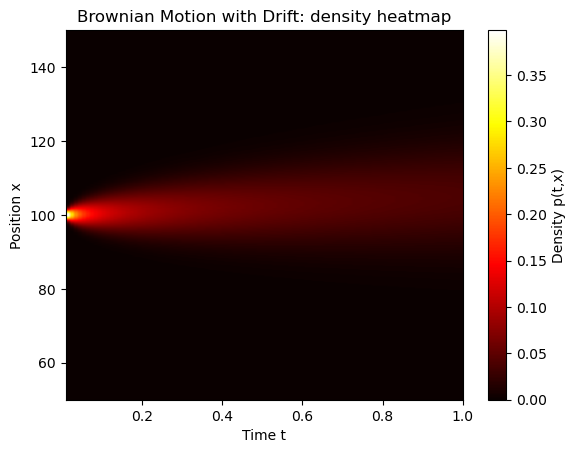

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def brownian_density(x, t, x0, mu, sigma2):
    # t can be array; x can be array; uses broadcasting
    return (1.0 / np.sqrt(2 * np.pi * sigma2 * t)) * np.exp(-(x - (x0 + mu * t))**2 / (2 * sigma2 * t))

def brownian_heatmap(x0, mu, sigma2, x_bounds, t_bounds, dx, dt):
    # start at small positive time to avoid division by zero
    T = np.arange(max(t_bounds[0], dt), t_bounds[1] + 1e-12, dt)
    X = np.arange(x_bounds[0], x_bounds[1] + 1e-12, dx)

    # Create grids: X along rows, T along columns
    XX = X[:, None]      # shape (len(X), 1)
    TT = T[None, :]      # shape (1, len(T))

    U = brownian_density(XX, TT, x0=x0, mu=mu, sigma2=sigma2)

    plt.imshow(
        U,
        extent=(T[0], T[-1], X[0], X[-1]),
        origin='lower',
        aspect='auto',
        cmap='hot'
    )
    plt.colorbar(label='Density p(t,x)')
    plt.xlabel('Time t')
    plt.ylabel('Position x')
    plt.title('Brownian Motion with Drift: density heatmap')
    plt.show()

# Parameters consistent with your earlier statement Var[X_1]=100
x0 = 100
mu = 5
sigma2 = 100   # variance rate (i.e., Var[X_t] = sigma2 * t)

x_bounds = [x0 - 50, x0 + 50]  # choose wide enough to see the spread
t_bounds = [0, 1]
dx = 0.25
dt = 0.01

brownian_heatmap(x0, mu, sigma2, x_bounds, t_bounds, dx, dt)


Calculating $\Phi\left(\frac{1}{\sqrt{2}}\right)$ using scipy

In [ ]:
from scipy.stats import norm
x = -1 / np.sqrt(2)
norm.cdf(x)


## Question 22

Calculating $2\left(1 - \Phi\left(1\right)\right)$ using scipy

In [ ]:
x = 1
2*(1 - norm.cdf(x))
b


Question 23

In [ ]:
l = sp.Rational(1,5); th = sp.symbols("theta")
print(sp.latex(l / (l - 5*th - 50*th**2)))

\frac{1}{5 \left(- 50 \theta^{2} - 5 \theta + \frac{1}{5}\right)}
